In [16]:
from processor.processor import Processor as processor
from extractor.alp_client_extractor import ALPClientExtractor
from database.adatabase import ADatabase
from xgboost import XGBRegressor
from statistics import mean
import math
import pandas as pd
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from tqdm import tqdm
from dotenv import load_dotenv
import os
import warnings
warnings.simplefilter(action="ignore")
load_dotenv()

True

In [17]:
start = datetime.now() - timedelta(days=365.25*2)
end = datetime.now()

In [18]:
key = os.getenv("APCAKEY")
secret = os.getenv("APCASECRET")
alp_client = ALPClientExtractor(key,secret)
account = alp_client.account()
cash = float(account["cash"])
factors =  ["AMZN","GOOGL","AAPL","NVDA","TSLA","MSFT","META"]
holding_period = 65
stoploss = 1
positions = 10
sec = ADatabase("sec")

In [19]:
def calculate_expected_return(row, factors):
    factor_loadings = [row[factor] * row[f"{factor}_beta"] for factor in factors]
    return np.mean(factor_loadings)

def error_function(sensitivity_weights, ticker_prices, factors):
    ticker_prices_copy = ticker_prices.copy()
    
    for i in range(len(factors)):
        ticker_prices_copy[f"{factors[i]}_beta"] *= (1 + sensitivity_weights[i])
    
    ticker_prices_copy["expected_return"] = ticker_prices_copy.apply(lambda row: calculate_expected_return(row, factors), axis=1)
    
    actual_returns = ticker_prices_copy["actual_return"]  # Assuming you have actual returns data
    expected_returns = ticker_prices_copy["expected_return"]
    
    # Calculate error (e.g., mean squared error)
    error = ((actual_returns - expected_returns) ** 2).mean()
    
    return error

In [20]:
## download constituents
sp500 = pd.read_html("https://en.wikipedia.org/wiki/List_of_S%26P_500_companies",attrs={"id":"constituents"})[0].rename(columns={"Symbol":"ticker"})
sp500

,ticker,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989
...,...,...,...,...,...,...,...,...
498,YUM,Yum! Brands,Consumer Discretionary,Restaurants,"Louisville, Kentucky",1997-10-06,1041061,1997
499,ZBRA,Zebra Technologies,Information Technology,Electronic Equipment & Instruments,"Lincolnshire, Illinois",2019-12-23,877212,1969
500,ZBH,Zimmer Biomet,Health Care,Health Care Equipment,"Warsaw, Indiana",2001-08-07,1136869,1927
501,ZION,Zions Bancorporation,Financials,Regional Banks,"Salt Lake City, Utah",2001-06-22,109380,1873


In [21]:
## download factors
factor_dfs = []
for ticker in factors:
    try:
        ticker_prices = processor.column_date_processing(alp_client.prices(ticker,start,end))[["date","ticker","adjclose"]]
        ticker_prices["historical_return"] = ticker_prices["adjclose"].pct_change(holding_period) 
        factor_dfs.append(ticker_prices)
    except Exception as e:
        print(str(e))
        continue
factor_df = pd.concat(factor_dfs).pivot_table(index="date",columns="ticker",values="historical_return").reset_index()
factor_df

ticker,date,AAPL,AMZN,GOOGL,META,MSFT,NVDA,TSLA
0,2022-06-21 04:00:00+00:00,-0.154090,-0.308827,-0.166617,-0.244371,-0.140505,-0.331099,-0.184112
1,2022-06-22 04:00:00+00:00,-0.174594,-0.324341,-0.181003,-0.280105,-0.157441,-0.381545,-0.217727
2,2022-06-23 04:00:00+00:00,-0.163926,-0.303734,-0.175312,-0.249373,-0.134711,-0.393095,-0.234424
3,2022-06-24 04:00:00+00:00,-0.160881,-0.293711,-0.156502,-0.214586,-0.119582,-0.354321,-0.258413
4,2022-06-27 04:00:00+00:00,-0.167734,-0.307142,-0.162352,-0.205987,-0.115530,-0.341929,-0.264593
...,...,...,...,...,...,...,...,...
432,2024-03-11 04:00:00+00:00,-0.106866,0.170752,0.050996,0.519338,0.085901,0.841988,-0.255320
433,2024-03-12 04:00:00+00:00,-0.099262,0.213604,0.065221,0.574264,0.126030,1.019933,-0.258303
434,2024-03-13 04:00:00+00:00,-0.119113,0.202036,0.020887,0.517407,0.119019,0.950554,-0.301517
435,2024-03-14 04:00:00+00:00,-0.116039,0.212522,0.060079,0.478077,0.136253,0.851219,-0.333579


In [22]:
simulation = []

for ticker in tqdm(sp500["ticker"]):
    try:
        ticker_prices = processor.column_date_processing(alp_client.prices(ticker,start,end))
        ticker_prices["ticker"] = ticker
        ticker_prices.sort_values("date",inplace=True)
        ## merging with factors
        ticker_prices = processor.merge(ticker_prices,factor_df.copy(),on="date")
        ticker_prices["historical_return"] = ticker_prices["adjclose"].pct_change(holding_period)
        for factor in factors:
            ticker_prices[f"{factor}_covariance"] = ticker_prices["historical_return"].rolling(100).cov(ticker_prices[factor])
            ticker_prices[f"{factor}_beta"] = ticker_prices[f"{factor}_covariance"] / ticker_prices[factor].rolling(100).var()
            ticker_prices[f"{factor}_loading"] = ticker_prices[factor] * ticker_prices[f"{factor}_beta"]
        ticker_prices.dropna(inplace=True)
        training_data = ticker_prices.iloc[:100]
        simulation_data = ticker_prices.iloc[100:]
        training_data["actual_return"] = training_data["adjclose"].pct_change(-holding_period)
        simulation_data["buy_date"] = simulation_data["date"].shift(-1)
        simulation_data["sell_date"] = simulation_data["date"].shift(-holding_period)
        simulation_data["buy_price"] = simulation_data["adjclose"].shift(-1)
        simulation_data["sell_price"] = simulation_data["adjclose"].shift(-holding_period)
        simulation_data["return"] = (simulation_data["sell_price"] - simulation_data["buy_price"]) / simulation_data["buy_price"]
        # Initial guess for sensitivity weights
        initial_guess = np.zeros(len(factors))
    
        # Perform optimization to find optimal sensitivity weights
        result = minimize(error_function, initial_guess, args=(training_data, factors), method='L-BFGS-B')
    
        # Optimal sensitivity weights
        optimal_sensitivity_weights = result.x
    
        # Apply optimal sensitivity weights to the end DataFrame
        for i in range(len(factors)):
            simulation_data[f"{factors[i]}_beta"] *= (1 + optimal_sensitivity_weights[i])
    
        # Calculate expected returns using the adjusted factor betas
        simulation_data["expected_return"] = simulation_data.apply(lambda row: calculate_expected_return(row, factors), axis=1)
    
        simulation.append(simulation_data)
    except Exception as e:
        print(str(e))
        continue

# After the loop
# Concatenate the simulation results
sim = pd.concat(simulation)

 93%|████████████████████████████████████████████████████████████████████████████████████████▏      | 467/503 [13:10<00:51,  1.44s/it]

attempt to get argmax of an empty sequence


100%|███████████████████████████████████████████████████████████████████████████████████████████████| 503/503 [14:09<00:00,  1.69s/it]


In [23]:
sim

,date,adjclose,ticker,year,quarter,month,week,weekday,AAPL,AMZN,...,MSFT_loading,META_covariance,META_beta,META_loading,buy_date,sell_date,buy_price,sell_price,return,expected_return
264,2023-04-05 04:00:00+00:00,102.29,MMM,2023,2,4,14,2,0.260371,0.203571,...,-0.044507,-0.026382,2.735448,-0.094664,2023-04-06 04:00:00+00:00,2023-07-11 04:00:00+00:00,101.56,101.92,0.003545,0.145854
265,2023-04-06 04:00:00+00:00,101.56,MMM,2023,2,4,14,3,0.316543,0.189233,...,-0.060135,-0.027487,2.865818,-0.095908,2023-04-10 04:00:00+00:00,2023-07-12 04:00:00+00:00,102.76,101.57,-0.011580,0.060767
266,2023-04-10 04:00:00+00:00,102.76,MMM,2023,2,4,15,0,0.282289,0.200023,...,-0.081035,-0.028410,2.986495,-0.093619,2023-04-11 04:00:00+00:00,2023-07-13 04:00:00+00:00,104.56,102.86,-0.016259,0.062846
267,2023-04-11 04:00:00+00:00,104.56,MMM,2023,2,4,15,1,0.286194,0.202117,...,-0.093237,-0.029368,3.117339,-0.097524,2023-04-12 04:00:00+00:00,2023-07-14 04:00:00+00:00,104.37,102.30,-0.019833,0.036427
268,2023-04-12 04:00:00+00:00,104.37,MMM,2023,2,4,15,2,0.235149,0.136501,...,-0.099806,-0.030340,3.257720,-0.096147,2023-04-13 04:00:00+00:00,2023-07-17 04:00:00+00:00,106.15,101.70,-0.041922,0.021430
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
497,2024-03-11 04:00:00+00:00,183.49,ZTS,2024,1,3,11,0,-0.106866,0.170752,...,0.071548,0.012524,2.019622,0.209119,2024-03-12 04:00:00+00:00,NaT,181.35,NaN,NaN,0.209218
498,2024-03-12 04:00:00+00:00,181.35,ZTS,2024,1,3,11,1,-0.099262,0.213604,...,0.109890,0.012322,1.927149,0.220648,2024-03-13 04:00:00+00:00,NaT,176.23,NaN,NaN,0.197868
499,2024-03-13 04:00:00+00:00,176.23,ZTS,2024,1,3,11,2,-0.119113,0.202036,...,0.111219,0.012001,1.851671,0.191016,2024-03-14 04:00:00+00:00,NaT,173.88,NaN,NaN,0.096950
500,2024-03-14 04:00:00+00:00,173.88,ZTS,2024,1,3,11,3,-0.116039,0.212522,...,0.135286,0.011610,1.788421,0.170467,2024-03-15 04:00:00+00:00,NaT,172.57,NaN,NaN,0.071217


In [24]:
trades = sim[sim["weekday"]==4].copy()
trades = trades[trades["week"] % int(holding_period/5) == 0]
trades.sort_values("date",inplace=True)
iteration_trades = trades.copy().sort_values("expected_return",ascending=False).groupby("date").nth([i for i in range(positions)]).reset_index()
iteration_trades.sort_values("date",inplace=True)
iteration_trades

,index,date,adjclose,ticker,year,quarter,month,week,weekday,AAPL,...,MSFT_loading,META_covariance,META_beta,META_loading,buy_date,sell_date,buy_price,sell_price,return,expected_return
0,311,2023-06-30 04:00:00+00:00,12.54,WBD,2023,2,6,26,4,0.230384,...,-0.403633,0.031762,176.415760,0.488883,2023-07-03 04:00:00+00:00,2023-10-03 04:00:00+00:00,13.01,10.35,-0.204458,18.363282
21,323,2023-06-30 04:00:00+00:00,18.55,GEN,2023,2,6,26,4,0.230384,...,0.112981,-0.003079,4.879532,-0.047398,2023-07-03 04:00:00+00:00,2023-10-03 04:00:00+00:00,18.45,17.36,-0.059079,1.141987
20,323,2023-06-30 04:00:00+00:00,36.68,PFE,2023,2,6,26,4,0.230384,...,0.101520,-0.003058,-0.224895,-0.047067,2023-07-03 04:00:00+00:00,2023-10-03 04:00:00+00:00,36.65,33.90,-0.075034,1.253586
19,323,2023-06-30 04:00:00+00:00,43.36,CTLT,2023,2,6,26,4,0.230384,...,-0.686598,0.054194,7.665044,0.834157,2023-07-03 04:00:00+00:00,2023-10-03 04:00:00+00:00,44.29,43.95,-0.007677,1.272289
18,323,2023-06-30 04:00:00+00:00,423.02,NVDA,2023,2,6,26,4,0.230384,...,0.237288,0.012061,-10.129661,0.185649,2023-07-03 04:00:00+00:00,2023-10-03 04:00:00+00:00,424.13,435.17,0.026030,1.404550
17,323,2023-06-30 04:00:00+00:00,33.44,INTC,2023,2,6,26,4,0.230384,...,0.244301,0.000616,-0.202167,0.009488,2023-07-03 04:00:00+00:00,2023-10-03 04:00:00+00:00,33.62,35.69,0.061570,1.505189
16,323,2023-06-30 04:00:00+00:00,56.68,SCHW,2023,2,6,26,4,0.230384,...,-0.117296,0.001680,-0.561395,0.025864,2023-07-03 04:00:00+00:00,2023-10-03 04:00:00+00:00,57.72,51.30,-0.111227,1.519376
15,323,2023-06-30 04:00:00+00:00,265.52,SHW,2023,2,6,26,4,0.230384,...,0.156808,-0.004273,-0.821521,-0.065775,2023-07-03 04:00:00+00:00,2023-10-03 04:00:00+00:00,264.13,248.77,-0.058153,1.520603
12,323,2023-06-30 04:00:00+00:00,41.13,EQT,2023,2,6,26,4,0.230384,...,0.308597,-0.018703,12.487966,-0.287878,2023-07-03 04:00:00+00:00,2023-10-03 04:00:00+00:00,40.68,39.62,-0.026057,2.292223
14,323,2023-06-30 04:00:00+00:00,58.00,LVS,2023,2,6,26,4,0.230384,...,-0.191132,0.013061,15.744800,0.201036,2023-07-03 04:00:00+00:00,2023-10-03 04:00:00+00:00,58.59,44.73,-0.236559,1.729841


In [25]:
iteration_trades["return"] = iteration_trades["return"] * (1/positions)
iteration_trades["return"] = [max(float(-stoploss/positions),x) for x in iteration_trades["return"]]
portfolio = iteration_trades[["date","return"]].groupby("date").sum().reset_index()
portfolio.sort_values("date",inplace=True)
portfolio = portfolio.iloc[:-1]
portfolio["year"] = [x.year for x in portfolio["date"]]
portfolio["return"] = portfolio["return"] + 1
portfolio["cumulative_return"] = portfolio["return"].cumprod()
portfolio

,date,return,year,cumulative_return
0,2023-06-30 04:00:00+00:00,0.930936,2023,0.930936
1,2023-09-29 04:00:00+00:00,1.248801,2023,1.162553


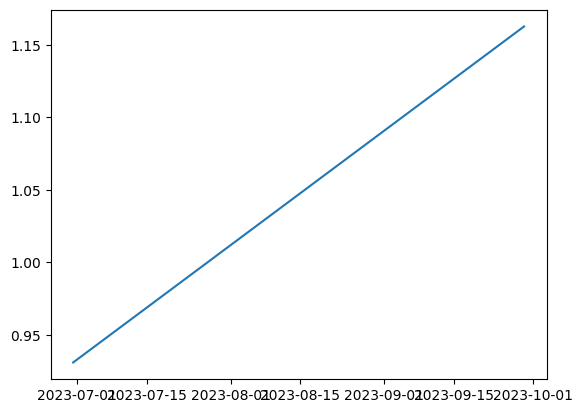

In [26]:
plt.plot(portfolio["date"].values,portfolio["cumulative_return"])

In [27]:
results = {}
results["number_of_trades"] = iteration_trades.index.size
results["standard_deviation"] = portfolio["cumulative_return"].std()
results["coefficient_of_variance"] = portfolio["cumulative_return"].std() / portfolio["cumulative_return"].mean()
results["sharpe"] = portfolio["cumulative_return"].iloc[-1] / portfolio["cumulative_return"].std()
results["return"] = portfolio["cumulative_return"].iloc[-1]
results = pd.DataFrame([results]).round(4).to_dict("records")[0]
results

{'number_of_trades': 30,
 'standard_deviation': 0.1638,
 'coefficient_of_variance': 0.1565,
 'sharpe': 7.0983,
 'return': 1.1626}

In [28]:
recommendations = iteration_trades[iteration_trades["date"]==iteration_trades["date"].max()].copy()
recommendations

,index,date,adjclose,ticker,year,quarter,month,week,weekday,AAPL,...,MSFT_loading,META_covariance,META_beta,META_loading,buy_date,sell_date,buy_price,sell_price,return,expected_return
1,449,2023-12-29 05:00:00+00:00,14.40,KEY,2023,4,12,52,4,0.129672,...,0.135516,0.006615,73.934412,0.195224,2024-01-02 05:00:00+00:00,NaT,14.61,NaN,-0.1,7.546067
10,449,2023-12-29 05:00:00+00:00,13.74,AAL,2023,4,12,52,4,0.129672,...,0.161319,0.009712,-27.082515,0.286612,2024-01-02 05:00:00+00:00,NaT,13.44,NaN,-0.1,2.607817
9,449,2023-12-29 05:00:00+00:00,495.22,NVDA,2023,4,12,52,4,0.129672,...,0.029895,0.011389,-41.765557,0.336096,2024-01-02 05:00:00+00:00,NaT,481.68,NaN,-0.1,2.832327
4,449,2023-12-29 05:00:00+00:00,46.88,CZR,2023,4,12,52,4,0.129672,...,-0.060831,0.010128,-6.590803,0.298878,2024-01-02 05:00:00+00:00,NaT,47.78,NaN,-0.1,3.531498
6,437,2023-12-29 05:00:00+00:00,11.38,WBD,2023,4,12,52,4,0.129672,...,0.030884,0.005705,138.360975,0.168356,2024-01-02 05:00:00+00:00,NaT,11.66,NaN,-0.1,3.346826
7,449,2023-12-29 05:00:00+00:00,34.49,FITB,2023,4,12,52,4,0.129672,...,0.215450,0.006948,72.995134,0.205049,2024-01-02 05:00:00+00:00,NaT,34.78,NaN,-0.1,3.189313
8,449,2023-12-29 05:00:00+00:00,12.72,HBAN,2023,4,12,52,4,0.129672,...,0.131618,0.008187,67.590806,0.241605,2024-01-02 05:00:00+00:00,NaT,12.86,NaN,-0.1,3.108177
11,449,2023-12-29 05:00:00+00:00,573.42,URI,2023,4,12,52,4,0.129672,...,0.043242,0.010727,20.338772,0.316565,2024-01-02 05:00:00+00:00,NaT,567.10,NaN,-0.1,2.398572
2,449,2023-12-29 05:00:00+00:00,70.17,BXP,2023,4,12,52,4,0.129672,...,-0.093592,0.009466,22.738164,0.279338,2024-01-02 05:00:00+00:00,NaT,72.10,NaN,-0.1,6.524702
3,449,2023-12-29 05:00:00+00:00,68.80,SCHW,2023,4,12,52,4,0.129672,...,0.102829,0.009906,-14.451567,0.292340,2024-01-02 05:00:00+00:00,NaT,69.10,NaN,-0.1,3.899900


In [29]:
# try:
#     positions = recommendations.index.size
#     notional = math.floor(float(cash/positions),2)
#     for row in recommendations.iterrows():
#         ticker = row[1]["ticker"]
#         print(alp_client.buy(ticker,notional))
# except Exception as e:
#     print(str(e))